In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
 
# === Step 1: Download Data ===
def download_data(ticker, period="5y"):
    df = yf.download(ticker, period=period)
    df = df[['Close', 'Volume']]
    df.dropna(inplace=True)
    return df

# === Step 2: Indicators ===
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_tsi(series, r=25, s=13):
    diff = series.diff()
    double_smoothed = diff.ewm(span=r).mean().ewm(span=s).mean()
    price_smoothed = series.ewm(span=r).mean().ewm(span=s).mean()
    tsi = 100 * (double_smoothed / price_smoothed)
    return tsi

# === Step 3: Additional Features ===
def add_additional_features(df):
    df['Return'] = df['Close'].pct_change()
    df['Volatility'] = df['Return'].rolling(window=10).std()
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA_Diff'] = df['MA5'] - df['MA20']
    df['Volume_Change'] = df['Volume'].pct_change()
    return df

# === Step 4: Create Labels ===
def create_labels(data, forward_days=15):
    future_return = data['Close'].shift(-forward_days) / data['Close'] - 1
    data['Label'] = (future_return > 0).astype(int)
    return data

# === Step 5: Prepare Data ===
def prepare_data_with_extra_features(df):
    df['RSI'] = compute_rsi(df['Close'])
    df['TSI'] = compute_tsi(df['Close'])
    df = add_additional_features(df)
    df = create_labels(df)
    df.dropna(inplace=True)

    features = ['RSI', 'TSI', 'Return', 'Volatility', 'MA_Diff', 'Volume_Change']
    X = df[features]
    y = df['Label']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    split_index = int(len(df) * 0.8)
    X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    df_train, df_test = df.iloc[:split_index], df.iloc[split_index:]

    return X_train, X_test, y_train, y_test, df_train, df_test, scaler, features

# === Step 6: Train Model ===
def train_model(X_train, y_train):
    model = XGBClassifier(eval_metric='logloss')
    model.fit(X_train, y_train)
    return model

# === Step 7: Backtest with Probabilities ===
def backtest_with_proba_filter(model, df_test, scaler, features, proba_threshold=0.6, forward_days=15):
    df_test = df_test.copy()
    X = scaler.transform(df_test[features])
    proba_preds = model.predict_proba(X)[:, 1]
    df_test['Signal'] = (proba_preds > proba_threshold).astype(int)

    df_test['Buy'] = 0
    df_test['Sell_Price'] = np.nan
    df_test['Strategy_Return'] = 0.0

    i = 0
    while i < len(df_test) - forward_days:
        if df_test['Signal'].iloc[i] == 1:
            buy_price = df_test['Close'].iloc[i]
            if i + forward_days < len(df_test):
                sell_price = df_test['Close'].iloc[i + forward_days]
                ret = (sell_price - buy_price) / buy_price
                df_test.at[df_test.index[i], 'Buy'] = 1
                df_test.at[df_test.index[i + forward_days], 'Sell_Price'] = sell_price
                df_test.at[df_test.index[i + forward_days], 'Strategy_Return'] = ret
            i += forward_days
        else:
            i += 1

    df_test['Strategy_CumRet'] = df_test['Strategy_Return'].fillna(0).cumsum()
    bh_return = (df_test['Close'].iloc[-1] - df_test['Close'].iloc[0]) / df_test['Close'].iloc[0]
    bh_return = float(bh_return)
    sharpe = df_test['Strategy_Return'].mean() / (df_test['Strategy_Return'].std() + 1e-9) * np.sqrt(252 / forward_days)

    return df_test, bh_return, df_test['Strategy_CumRet'].iloc[-1], sharpe

# === Step 8: Visualization ===
def visualize_results(df_test, cumulative_return, bh_return):
    plt.figure(figsize=(12, 6))
    strategy_cum_returns = df_test['Strategy_CumRet']
    strategy_cum_returns.plot(label='Strategy Cumulative Return')

    bh_line = pd.Series([0] + [bh_return] * (len(strategy_cum_returns) - 1), index=strategy_cum_returns.index)
    bh_line.plot(label='Buy & Hold Return', linestyle='--')

    plt.title("Strategy vs Buy & Hold Cumulative Returns")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Step 9: Real-time Prediction ===
def predict_on_date(model, df, date, scaler, features, threshold=0.6):
    try:
        row = df.loc[date]
    except KeyError:
        return f"Date {date} not in the data."

    row_input = scaler.transform([row[features].values])
    proba = model.predict_proba(row_input)[0][1]
    return f"BUY (prob={proba:.2f})" if proba > threshold else f"DO NOT BUY (prob={proba:.2f})"

# === Step 10: Main Function ===
def run_strategy_enhanced(ticker, proba_threshold=0.6):
    print(f"\nRunning enhanced mean reversion strategy with XGBoost using Yahoo Finance data for: {ticker}")

    df = download_data(ticker)
    X_train, X_test, y_train, y_test, df_train, df_test, scaler, features = prepare_data_with_extra_features(df)
    model = train_model(X_train, y_train)

    df_test_eval, bh_return, strat_return, sharpe = backtest_with_proba_filter(
        model, df_test, scaler, features, proba_threshold=proba_threshold
    )

    print("\n📊 Enhanced Strategy Evaluation Results:")
    print(f"Probability Threshold: {proba_threshold}")
    print(f"Strategy Cumulative Return: {strat_return:.2%}")
    print(f"Buy & Hold Return: {bh_return:.2%}")
    print(f"Strategy Sharpe Ratio: {sharpe:.2f}")
    print(f"Number of Executed Trades: {int(df_test_eval['Buy'].sum())}")

    visualize_results(df_test_eval, strat_return, bh_return)

    return model, df, scaler, features


ModuleNotFoundError: No module named 'xgboost'


Running enhanced mean reversion strategy with XGBoost using Yahoo Finance data for: SPY


[*********************100%***********************]  1 of 1 completed
<ipython-input-56-d77933ab8afa>:102: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  bh_return = float(bh_return)



📊 Enhanced Strategy Evaluation Results:
Probability Threshold: 0.6
Strategy Cumulative Return: 0.00%
Buy & Hold Return: 6.53%
Strategy Sharpe Ratio: 0.00
Number of Executed Trades: 16


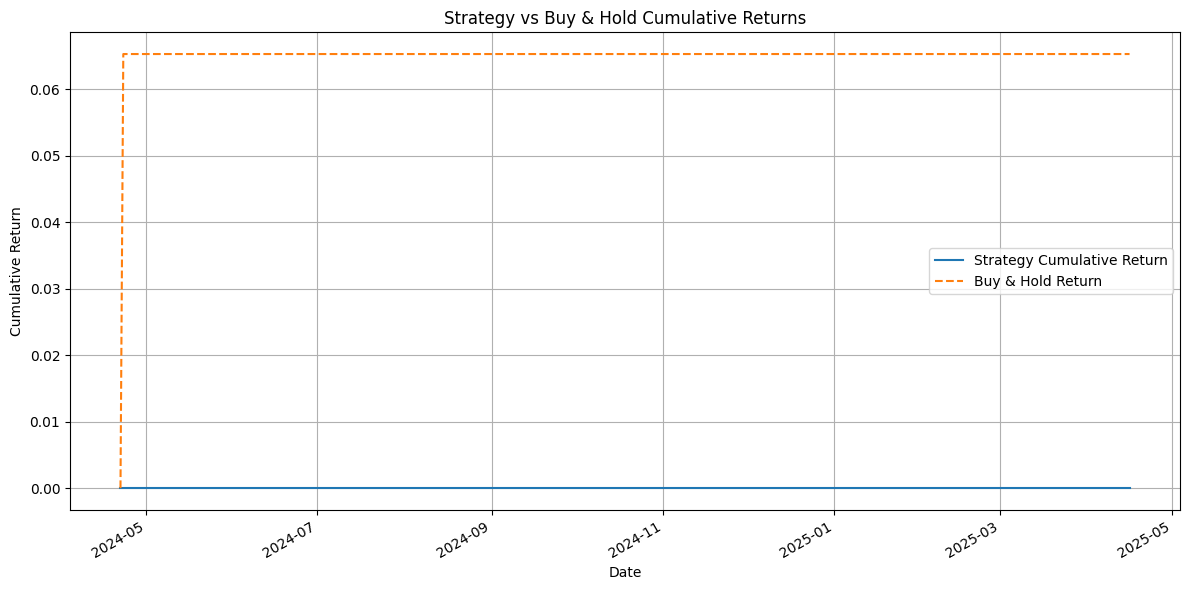

In [57]:
model, df_full, scaler, features = run_strategy_enhanced("SPY", proba_threshold=0.6)
